In [33]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import os 
import numpy as np

import tensorflow as tf
from tensorflow import keras # type: ignore
from keras import Model, Input
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Layer, Reshape, Conv2DTranspose, Multiply, Add, Lambda
from tensorflow.python.client import device_lib
from keras import backend as K

from matplotlib import pyplot as plt
from keras.datasets import mnist


from numpy import random



In [67]:
def plot_label_clusters(model, data, labels):
    z_mean, _, _, = model.predict(data)
    plt.figure(figsize=(4, 4))
    plt.scatter(z_mean[:,0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.show()

# Preparing Dataset

In [22]:
(X_train, y_train), (_, _) = mnist.load_data()

In [23]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [24]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [25]:
print(f"Before reshaping X_train has a shape of : {X_train.shape}")

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))

print(f"AFter reshaping X_train has a shape of : {X_train.shape}")

Before reshaping X_train has a shape of : (60000, 28, 28)
AFter reshaping X_train has a shape of : (60000, 28, 28, 1)


In [26]:
X_train = tf.cast(X_train, tf.float32)
X_train = X_train / 255.0

In [27]:
dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28, 1), dtype=tf.float32, name=None)>

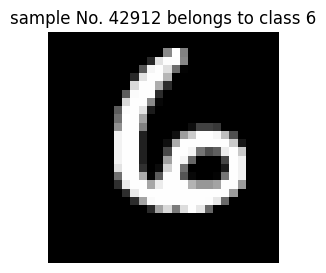

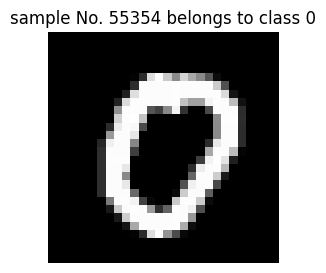

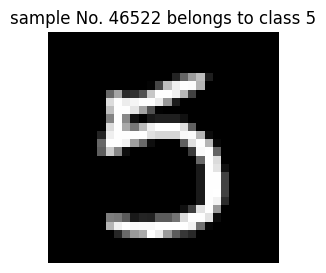

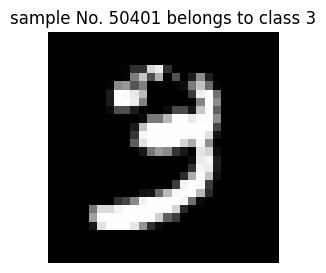

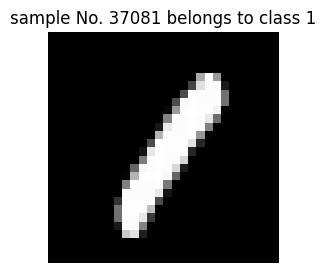

In [28]:
for r in random.randint(0, 59999, size=5, dtype=int):

    plt.figure(figsize=(3,3))
    plt.imshow(X_train[r, :,:,0], cmap='gray')
    plt.title('sample No. {} belongs to class {}'.format(r, y_train[r]))
    plt.axis("off")

# Variational Autoencoder

 <center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/autoencoder.png"" width="800" alt="computer components"  />
<center>

## Encoder


<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/encoder.png" width="30%" alt="computer components"/></center>


In [29]:
encoder_input = Input(shape=(28,28, 1))
x = Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_input)
x = Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)

encoder_output = Dense(16, activation='relu')(x)

 <center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/mean_var.png" height="300" alt="computer components"  />
<center>


In [32]:
latent_dim = 2

mean = Dense(latent_dim, name="mean")(encoder_output)
log_var = Dense(latent_dim, name='z_log_var')(encoder_output)
sigma = Lambda(lambda t: tf.exp(0.5 * t), name = 'sigma')(log_var)

In [36]:
epsilon = Lambda(lambda m: keras.random.normal(shape=keras.ops.shape(m)))(mean)

In [38]:
z_eps = Multiply()([sigma, epsilon])
z = Add()([mean, z_eps])

In [39]:
encoder = Model(encoder_input, outputs= [mean, log_var, z], name = 'encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │         34 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigma (Lambda)      │ (None, 2)         │          0 │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ mean[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 2)         │          0 │ sigma[0][0],      │
│ (Multiply)          │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2)         │          0 │ mean[0][0],       │
│                     │                   │            │ multiply_4[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/decoder.png" width="400" alt="computer components"  />
<center>

In [40]:
latent_dim = 2
decoder = Sequential()

decoder.add(Input(shape = (latent_dim, )))
decoder.add(Dense(7*7  * 64, activation='relu'))
decoder.add(Reshape((7, 7, 64)))
decoder.add(Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same'))
decoder.add(Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same'))
decoder.add(Conv2DTranspose(1, 3, activation='sigmoid', padding='same'))
decoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def reconstruction_loss(y, yhat):
    return tf.reduce_mean(tf.square(y - yhat))

def kl_loss(mu, log_var):
    loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
    return loss

def vae_logg(y_true, yhat, mu, log_var):
    return reconstruction_loss(y_true, yhat) + (1.0/(64*64)) * kl_loss(mu, log_var)

In [ ]:
from keras import ops  # type: ignore

def reconstruction_loss(y, yhat):
    return ops.mean(ops.square(y - yhat))  # consistent Keras ops

def kl_loss(mu, log_var):
    # Use ops.mean, ops.square, ops.exp for symbolic tensors
    loss = -0.5 * ops.mean(1 + log_var - ops.square(mu) - ops.exp(log_var))
    return loss

def vae_logg(y_true, yhat, mu, log_var):
    return reconstruction_loss(y_true, yhat) + (1.0 / (64 * 64)) * kl_loss(mu, log_var)

# Assume encoder_input is defined, e.g., Input(shape=(64,64,3))
mean, log_var, z = encoder(encoder_input)
reconstructed = decoder(z)

model = tf.keras.Model(encoder_input, reconstructed, name='vae')
loss = kl_loss(mean, log_var)
model.add_loss(loss)
model.summary()

NotImplementedError: 

In [57]:
print("Type of mean:", type(mean))
print("Type of log_var:", type(log_var))
print("Shape of mean:", mean.shape if hasattr(mean, 'shape') else 'No shape')
print("Shape of log_var:", log_var.shape if hasattr(log_var, 'shape') else 'No shape')

Type of mean: <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
Type of log_var: <class 'keras.src.backend.common.keras_tensor.KerasTensor'>
Shape of mean: (None, 2)
Shape of log_var: (None, 2)


In [ ]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        # Encode
        mean, log_var, z = self.encoder(inputs)
        # Decode
        reconstructed = self.decoder(z)

        # --- KL divergence loss ---
        kl_loss = -0.5 * ops.mean(1 + log_var - ops.square(mean) - ops.exp(log_var))
        self.add_loss(kl_loss)  

        return reconstructed

In [64]:
model = VAE(encoder, decoder, name='vae')
model.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ [(None, 2), (None, 2), │        69,076 │
│                                 │ (None, 2)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,165 (524.08 KB)

 Trainable params: 134,165 (524.08 KB)

 Non-trainable params: 0 (0.00 B)

Samples generated by decoder after 0 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


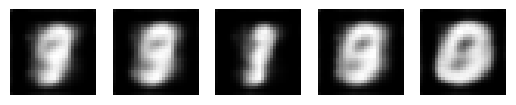

2D latent representations of the training data produced by encoder after 0 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


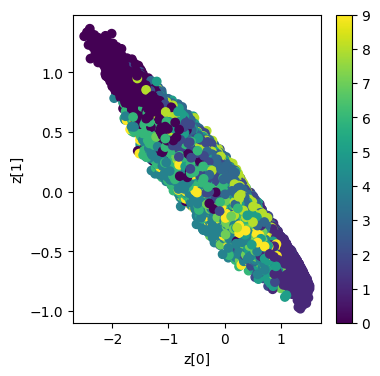

Epoch: 0 - Step: 599 - MSE loss: 0.06319286 - KL loss: 0.36026323
Samples generated by decoder after 1 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


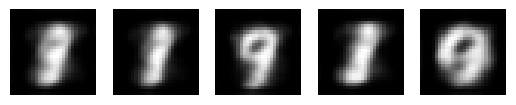

2D latent representations of the training data produced by encoder after 1 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


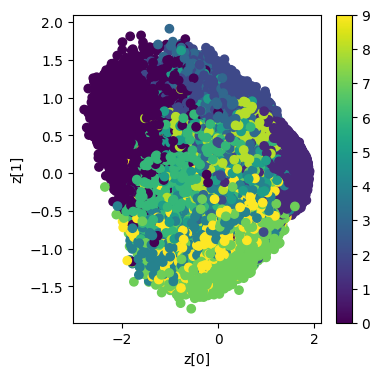

Epoch: 1 - Step: 599 - MSE loss: 0.06351123 - KL loss: 0.40671754
Samples generated by decoder after 2 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


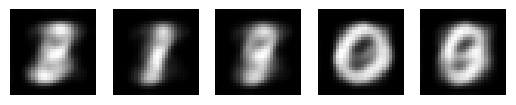

2D latent representations of the training data produced by encoder after 2 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


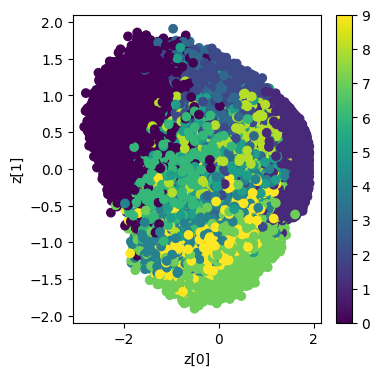

Epoch: 2 - Step: 599 - MSE loss: 0.0625932 - KL loss: 0.46647534
Samples generated by decoder after 3 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


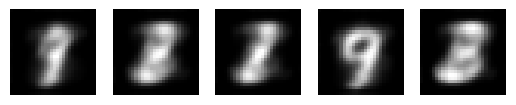

2D latent representations of the training data produced by encoder after 3 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


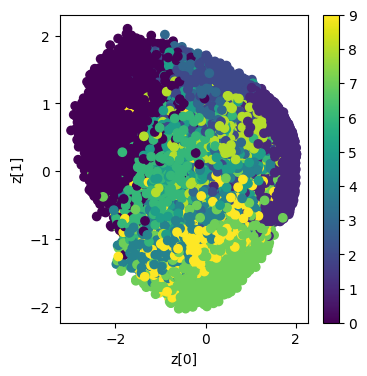

Epoch: 3 - Step: 599 - MSE loss: 0.06142902 - KL loss: 0.49902493
Samples generated by decoder after 4 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


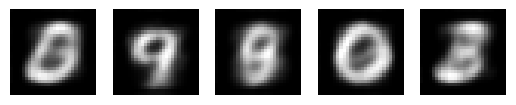

2D latent representations of the training data produced by encoder after 4 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


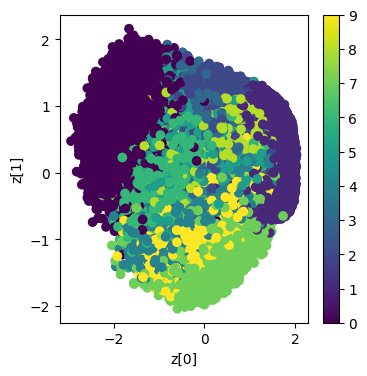

Epoch: 4 - Step: 599 - MSE loss: 0.06115109 - KL loss: 0.49933052


In [69]:
#loss
mse_losses = []
kl_losses = []
# optimizer 
optimizer =  tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999 )
epochs = 5

for epoch in range(epochs):
    
    print(f"Samples generated by decoder after {epoch} epoch(s): ")
    
    #random noise
    z = tf.random.normal(shape = (5, latent_dim,))

    # input random noise into the decoder
    xhat = decoder.predict(z)
    
    # plot the decoder output
    plt.figure()
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(xhat[i,:,:,0],cmap="gray")
        plt.axis("off")
    plt.show()

    print(f"2D latent representations of the training data produced by encoder after {epoch} epoch(s): ")
    plot_label_clusters(encoder, X_train, y_train)


    # training steps
    for (step, training_batch) in enumerate(dataset.batch(100)):
        with tf.GradientTape() as tape:

            # model output
            reconstructed = model(training_batch)

            y_true = tf.reshape(training_batch, shape = [-1])
            y_pred = tf.reshape(reconstructed, shape = [-1])

            # calculate reconstruction loss
            mse_loss = reconstruction_loss(y_true, y_pred)
            # calculate KL divergence
            kl = sum(model.losses)

            kl_losses.append(kl.numpy())
            mse_losses.append(mse_loss .numpy())

            # total loss
            train_loss = 0.01 * kl + mse_loss

            grads = tape.gradient(train_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
         
    print("Epoch: %s - Step: %s - MSE loss: %s - KL loss: %s" % (epoch, step, mse_loss.numpy(), kl.numpy()))
  

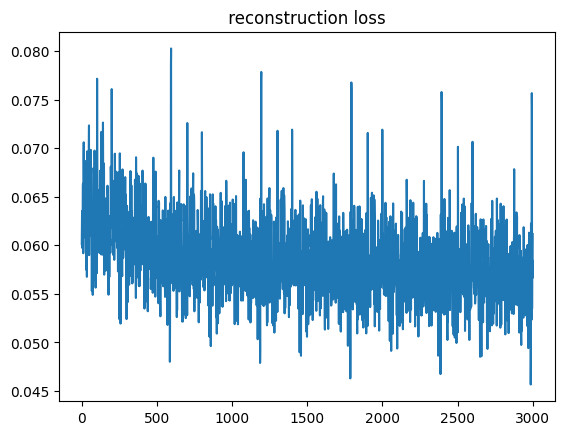

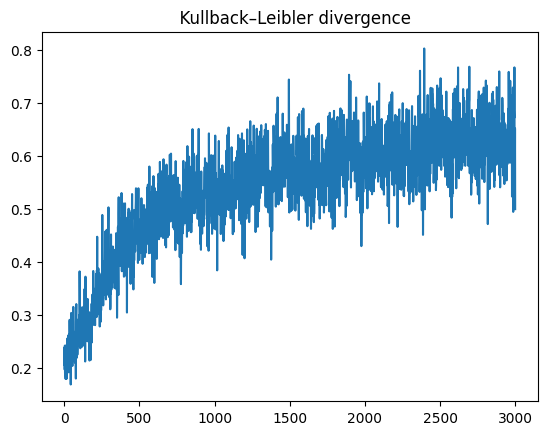

In [70]:
plt.plot(mse_losses)
plt.title(" reconstruction loss ")
plt.show()
plt.plot(kl_losses)
plt.title("  Kullback–Leibler divergence")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


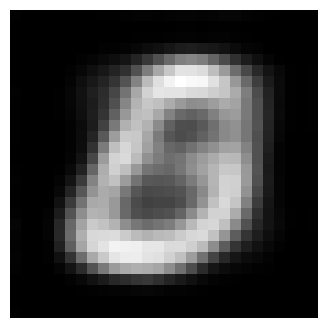

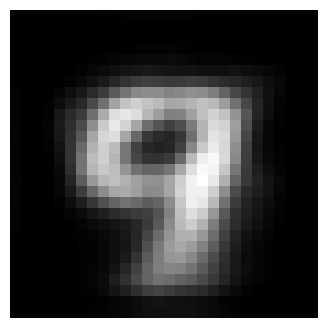

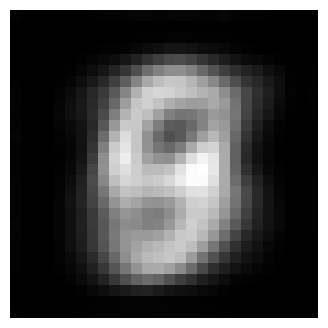

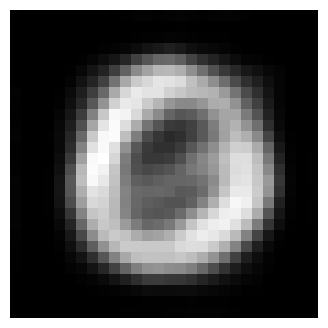

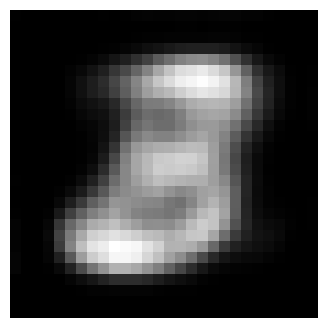

In [72]:
xhat = decoder.predict(z)

for i in range(5):
    plt.figure(figsize=(4,4))
    plt.imshow(xhat[i,:,:,0],cmap="gray")
    plt.axis('off')
    plt.show()

In [77]:
model.save_weights("./weights/last.weights.h5")